# 07 - Cumulative M0 Overnight Architecture Sweep — 20.03.2026

This notebook is the **`05`-compatible overnight follow-up** to the architecture audit.

It deliberately moves back toward the long-horizon logic from [05_long_horizon_inertia_experiments_16032026.ipynb](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/05_long_horizon_inertia_experiments_16032026.ipynb):

- same **direct forecasting** setup,
- same **train/test split logic**,
- same **full training history up to `2023-12-31 23:00`**,
- same **internal fit-validation split**,
- same **M0 temporal core**,
- but now extended to a **cumulative-only architecture sweep**.

The key distinction to keep in mind is:

- **training history** = all issue windows available in the train period,
- **lookback** = how many past hourly rows one prediction sees.

So even `lookback=48` or `lookback=72` still trains on the full historical train set; it only changes the per-sample context length.


In [1]:
# Section 0 - Fast runtime and pipeline sanity check
# This cell is intentionally quick: it checks the runtime, the file paths, the M0 columns,
# and runs one tiny 1-epoch smoke fit on U06 before the overnight loop is started.

from __future__ import annotations

from pathlib import Path
import os
import sys
import platform
import time
import warnings
from typing import Dict, List, Tuple

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '3')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/codex-mplconfig')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
    absl.logging.set_stderrthreshold('error')
except Exception:
    pass

from IPython.display import Markdown, display

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

try:
    tf.get_logger().setLevel('ERROR')
except Exception:
    pass
warnings.filterwarnings('ignore', message='.*use_unbounded_threadpool.*')
warnings.filterwarnings('ignore', message='.*IProgress not found.*')
sns.set_theme(style='whitegrid')

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

cwd = Path.cwd()
if cwd.name == 'thesis-project':
    PROJECT_ROOT = cwd
elif (cwd / 'thesis-project').exists():
    PROJECT_ROOT = cwd / 'thesis-project'
else:
    PROJECT_ROOT = cwd

DATA_DIR = PROJECT_ROOT / 'data'
FEATURE_DIR = DATA_DIR / 'features'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_METADATA_FILE = FEATURE_DIR / 'feature_metadata.csv'
PORTFOLIO_COVERAGE_FILE = FEATURE_DIR / 'portfolio_coverage.csv'

RUN_BUILDINGS = ['U05', 'U06', 'LIB', 'U02B', 'SOC', 'U03']
RUN_HORIZONS = [1, 4, 8, 10, 12, 16, 20, 24, 36]
TRAIN_END = pd.Timestamp('2023-12-31 23:00:00')
TEST_START = TRAIN_END + pd.Timedelta(hours=1)
FIT_VALIDATION_FRACTION = 0.10
BATCH_SIZE = 64
EPOCHS = 35
EARLY_STOPPING_PATIENCE = 6
LEARNING_RATE = 1e-3

M0_COLS = [
    'feat_heat_obs',
    'feat_outdoor_temp_c',
    'feat_wind_ms',
    'feat_solar_irradiance_wm2',
    'feat_hour_sin',
    'feat_hour_cos',
    #'feat_dow_sin',
    # 'feat_dow_cos',
]

ARCHITECTURES = {
    'A0': {
        'architecture_id': 'A0',
        'architecture_label': 'stacked 64 -> 32 | L24',
        'lookback_hours': 24,
        'lstm_stack': [64, 32],
        'dropout': 0.2,
        'dense_units': 16,
        'notes': 'Exact 05-style baseline architecture.',
    },
    'A1': {
        'architecture_id': 'A1',
        'architecture_label': 'stacked 64 -> 32 | L48',
        'lookback_hours': 48,
        'lstm_stack': [64, 32],
        'dropout': 0.2,
        'dense_units': 16,
        'notes': 'Same topology as A0, longer context.',
    },
    'A2': {
        'architecture_id': 'A2',
        'architecture_label': 'stacked 64 -> 32 | L72',
        'lookback_hours': 72,
        'lstm_stack': [64, 32],
        'dropout': 0.2,
        'dense_units': 16,
        'notes': 'Same topology as A0, longest context in this sweep.',
    },
    'A3': {
        'architecture_id': 'A3',
        'architecture_label': 'single 64 | L48',
        'lookback_hours': 48,
        'lstm_stack': [64],
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Lean single-layer alternative suggested by the audit.',
    },
    'A4': {
        'architecture_id': 'A4',
        'architecture_label': 'single 128 | L48',
        'lookback_hours': 48,
        'lstm_stack': [128],
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Wider single-layer alternative.',
    },
    'A5': {
        'architecture_id': 'A5',
        'architecture_label': 'single 64 | L24',
        'lookback_hours': 24,
        'lstm_stack': [64],
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Single-layer control with the original 24h context.',
    },
    'A6': {
        'architecture_id': 'A6',
        'architecture_label': 'single 64 | L72',
        'lookback_hours': 72,
        'lstm_stack': [64],
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Single-layer extension with a longer 72h context.',
    },
    'A7': {
        'architecture_id': 'A7',
        'architecture_label': 'single 64 | L168',
        'lookback_hours': 168,
        'lstm_stack': [64],
        'dropout': 0.0,
        'dense_units': 16,
        'notes': 'Single-layer weekly-context test to see whether broader recurring patterns help.',
    },
}

TOTAL_FITS = len(RUN_BUILDINGS) * len(RUN_HORIZONS) * len(ARCHITECTURES)

runtime_rows = [
    {'check_name': 'python_executable', 'value': sys.executable, 'status': 'INFO'},
    {'check_name': 'python_architecture', 'value': platform.machine(), 'status': 'PASS' if platform.machine() == 'arm64' else 'WARN'},
    {'check_name': 'tensorflow_version', 'value': tf.__version__, 'status': 'INFO'},
    {'check_name': 'tensorflow_devices', 'value': str(tf.config.list_physical_devices()), 'status': 'INFO'},
    {'check_name': 'gpu_visible_to_tensorflow', 'value': str(tf.config.list_physical_devices('GPU')), 'status': 'PASS' if tf.config.list_physical_devices('GPU') else 'WARN'},
    {'check_name': 'project_root', 'value': str(PROJECT_ROOT), 'status': 'INFO'},
    {'check_name': 'total_planned_fits', 'value': str(TOTAL_FITS), 'status': 'INFO'},
]
runtime_check_df = pd.DataFrame(runtime_rows)
display(runtime_check_df)


def set_all_seeds(seed: int) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def add_cumulative_targets(df: pd.DataFrame, horizons: List[int]) -> pd.DataFrame:
    out = df.copy()
    heat = out['heat_kwh'].astype(float)
    for horizon in horizons:
        out[f'target_cum_h{horizon}'] = sum(heat.shift(-i) for i in range(horizon))
    return out


def build_sequences(
    df_scaled: pd.DataFrame,
    dynamic_cols: List[str],
    target_col: str,
    split_mask: np.ndarray,
    lookback: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    X_list, y_list, ts_list = [], [], []
    mask = np.asarray(split_mask, dtype=bool)
    for end_idx in range(lookback, len(df_scaled)):
        if not mask[end_idx]:
            continue
        start_idx = end_idx - lookback
        if not mask[start_idx:end_idx].all():
            continue
        window = df_scaled.iloc[start_idx:end_idx]
        target_val = df_scaled.iloc[end_idx][target_col]
        if window[dynamic_cols].isna().any().any() or pd.isna(target_val):
            continue
        X_list.append(window[dynamic_cols].values.astype('float32'))
        y_list.append(float(target_val))
        ts_list.append(pd.Timestamp(df_scaled.iloc[end_idx]['datetime']))
    if not X_list:
        return (
            np.empty((0, lookback, len(dynamic_cols)), dtype='float32'),
            np.empty((0,), dtype='float32'),
            np.empty((0,), dtype='datetime64[ns]'),
        )
    return (
        np.stack(X_list, axis=0),
        np.array(y_list, dtype='float32'),
        np.array(ts_list, dtype='datetime64[ns]'),
    )


def make_optimizer(learning_rate: float):
    try:
        return tf.keras.optimizers.legacy.Adam(learning_rate=learning_rate)
    except Exception:
        return keras.optimizers.Adam(learning_rate=learning_rate)


def build_lstm_from_spec(n_timesteps: int, n_features: int, spec: Dict, learning_rate: float) -> keras.Model:
    temporal_in = keras.Input(shape=(n_timesteps, n_features), name='temporal_input')
    x = temporal_in
    stack = spec['lstm_stack']
    for layer_idx, units in enumerate(stack, start=1):
        return_sequences = layer_idx < len(stack)
        x = layers.LSTM(units, return_sequences=return_sequences, name=f'lstm_{layer_idx}')(x)
        if return_sequences and spec['dropout'] > 0:
            x = layers.Dropout(spec['dropout'], name=f'dropout_{layer_idx}')(x)
    x = layers.Dense(spec['dense_units'], activation='relu', name='dense_1')(x)
    out = layers.Dense(1, name='output')(x)
    model = keras.Model(inputs=temporal_in, outputs=out, name=spec['architecture_id'])
    model.compile(optimizer=make_optimizer(learning_rate), loss='mse', metrics=['mse'])
    return model


feature_meta = pd.read_csv(FEATURE_METADATA_FILE)
feature_paths = feature_meta.set_index('building')['path_setA'].to_dict()

sanity_rows = []
quick_ok = True
quick_messages = []
try:
    sanity_building = 'U06'
    sanity_horizon = 8
    sanity_arch = ARCHITECTURES['A0']
    sanity_path = PROJECT_ROOT / feature_paths[sanity_building]
    if not sanity_path.exists():
        raise FileNotFoundError(sanity_path)

    sanity_df = pd.read_csv(sanity_path, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)
    missing_cols = sorted(set(M0_COLS + ['heat_kwh']) - set(sanity_df.columns))
    if missing_cols:
        raise ValueError(f'Missing M0 columns in {sanity_building}: {missing_cols}')

    sanity_df = add_cumulative_targets(sanity_df, [sanity_horizon])
    target_name = f'target_cum_h{sanity_horizon}'
    feature_train_mask = pd.to_datetime(sanity_df['datetime']) <= TRAIN_END
    target_train_mask = pd.to_datetime(sanity_df['datetime']) <= TRAIN_END - pd.Timedelta(hours=sanity_horizon - 1)
    test_mask = pd.to_datetime(sanity_df['datetime']) >= TEST_START

    scaler_X = StandardScaler().fit(sanity_df.loc[feature_train_mask, M0_COLS].values)
    scaler_y = StandardScaler().fit(sanity_df.loc[target_train_mask, [target_name]].dropna().values)

    sanity_scaled = sanity_df.copy()
    sanity_scaled[M0_COLS] = scaler_X.transform(sanity_scaled[M0_COLS].values)
    sanity_scaled[f'{target_name}_scaled'] = np.nan
    nonnull = sanity_scaled[target_name].notna()
    sanity_scaled.loc[nonnull, f'{target_name}_scaled'] = scaler_y.transform(sanity_scaled.loc[nonnull, [target_name]].values).reshape(-1)

    X_train_full, y_train_full, _ = build_sequences(
        sanity_scaled,
        M0_COLS,
        f'{target_name}_scaled',
        target_train_mask.values,
        sanity_arch['lookback_hours'],
    )
    X_test, y_test, _ = build_sequences(
        sanity_scaled,
        M0_COLS,
        f'{target_name}_scaled',
        test_mask.values,
        sanity_arch['lookback_hours'],
    )

    if X_train_full.shape[0] < 64 or X_test.shape[0] < 32:
        raise ValueError('Not enough sequences for a meaningful smoke fit.')

    n_val = min(128, max(32, int(round(X_train_full.shape[0] * 0.10))))
    n_val = min(n_val, X_train_full.shape[0] - 1)
    split_at = X_train_full.shape[0] - n_val
    X_train = X_train_full[:split_at][:512]
    y_train = y_train_full[:split_at][:512]
    X_val = X_train_full[split_at:][:128]
    y_val = y_train_full[split_at:][:128]

    set_all_seeds(SEED)
    tf.keras.backend.clear_session()
    smoke_model = build_lstm_from_spec(sanity_arch['lookback_hours'], len(M0_COLS), sanity_arch, LEARNING_RATE)
    smoke_history = smoke_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=1,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    y_pred_scaled = smoke_model.predict(X_val[:64], verbose=0).reshape(-1, 1)
    y_true = scaler_y.inverse_transform(y_val[:64].reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    smoke_rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    quick_messages.append(
        f'Smoke fit PASS on {sanity_building}, {target_name}, {sanity_arch["architecture_id"]}: '
        f'train_seq={X_train_full.shape[0]}, test_seq={X_test.shape[0]}, 1-epoch val RMSE={smoke_rmse:.2f}'
    )
except Exception as exc:
    quick_ok = False
    quick_messages.append(f'Smoke fit failed: {type(exc).__name__}: {exc}')

status_text = 'PASS' if quick_ok else 'WARN'
display(Markdown(f"""
### Fast sanity check

- **Status:** `{status_text}`
- **Interpretation:** this quick check only verifies that the runtime, the exported `setA` features, the cumulative target construction, the sequence builder, the scaler logic, and one tiny LSTM fit all work together.
- **Next step if PASS:** start the overnight loop.
- **Next step if WARN:** do **not** start the overnight loop before fixing the issue below.

{'<br>'.join('- ' + msg for msg in quick_messages)}
"""))


/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,check_name,value,status
0,python_executable,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,INFO
1,python_architecture,arm64,PASS
2,tensorflow_version,2.19.1,INFO
3,tensorflow_devices,"[PhysicalDevice(name='/physical_device:CPU:0',...",INFO
4,gpu_visible_to_tensorflow,"[PhysicalDevice(name='/physical_device:GPU:0',...",PASS
5,project_root,/Users/mihkeluutar/Documents/TalTech/Thesis/th...,INFO
6,total_planned_fits,432,INFO


I0000 00:00:1774037846.865307  414418 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1774037846.865514  414418 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)



### Fast sanity check

- **Status:** `PASS`
- **Interpretation:** this quick check only verifies that the runtime, the exported `setA` features, the cumulative target construction, the sequence builder, the scaler logic, and one tiny LSTM fit all work together.
- **Next step if PASS:** start the overnight loop.
- **Next step if WARN:** do **not** start the overnight loop before fixing the issue below.

- Smoke fit PASS on U06, target_cum_h8, A0: train_seq=15364, test_seq=8199, 1-epoch val RMSE=212.71


## Section 1 - Experiment design

This notebook keeps the **direct long-horizon style** from `05`, but narrows the question to the one that matters now:

- keep the feature block fixed at **`M0`**,
- keep the training split logic fixed,
- keep the data source fixed to **`setA`** exports,
- and test whether a small architecture family and longer lookbacks improve cumulative forecasting.

The sweep is deliberately cumulative-first. The default target set is:

- `cum_h1`
- `cum_h4`
- `cum_h8`
- `cum_h10`
- `cum_h12`
- `cum_h16`
- `cum_h20`
- `cum_h24`
- `cum_h36`

This means the overnight run answers a more thesis-relevant question than the earlier point-target runs, while still remaining directly comparable to `05` in terms of split logic and training setup.

Compared with the first draft of this notebook, the overnight sweep now also includes a focused `single 64` lookback ladder at `24h`, `48h`, `72h`, and `168h`, so the run can use the available night-time budget to test whether longer context really helps once the feature block is held fixed.


In [2]:
# Section 1a - Metadata, feature blocks, target specs, and architecture catalog

feature_meta = pd.read_csv(FEATURE_METADATA_FILE)
portfolio_cov = pd.read_csv(PORTFOLIO_COVERAGE_FILE, parse_dates=['first_obs', 'last_obs'])
feature_paths = feature_meta.set_index('building')['path_setA'].to_dict()

missing_buildings = [b for b in RUN_BUILDINGS if b not in feature_paths]
if missing_buildings:
    raise ValueError(f'Missing feature metadata for buildings: {missing_buildings}')

TARGET_SPECS = [
    {
        'target_name': f'target_cum_h{h}',
        'target_family': 'cumulative',
        'horizon_hours': int(h),
    }
    for h in RUN_HORIZONS
]

target_specs_df = pd.DataFrame(TARGET_SPECS)
architecture_catalog_df = pd.DataFrame(ARCHITECTURES.values())

RUNLOG_FILE = RESULTS_DIR / 'cumulative_m0_overnight_architecture_run_log_20032026.csv'
CHECKPOINT_FILE = RESULTS_DIR / 'cumulative_m0_overnight_architecture_checkpoint_20032026.csv'
COVERAGE_FILE = RESULTS_DIR / 'cumulative_m0_overnight_architecture_coverage_20032026.csv'
SUMMARY_HORIZON_FILE = RESULTS_DIR / 'cumulative_m0_overnight_architecture_summary_by_horizon_20032026.csv'
SUMMARY_OVERALL_FILE = RESULTS_DIR / 'cumulative_m0_overnight_architecture_summary_overall_20032026.csv'
BEST_FILE = RESULTS_DIR / 'cumulative_m0_overnight_architecture_best_by_horizon_20032026.csv'

print('Buildings    :', RUN_BUILDINGS)
print('Mode         : M0 only')
print('Horizons     :', RUN_HORIZONS)
print('Architectures:', architecture_catalog_df['architecture_id'].tolist())
print('Total fits   :', TOTAL_FITS)

display(target_specs_df)
display(architecture_catalog_df[['architecture_id', 'architecture_label', 'lookback_hours', 'lstm_stack', 'dropout', 'dense_units', 'notes']])


Buildings    : ['U05', 'U06', 'LIB', 'U02B', 'SOC', 'U03']
Mode         : M0 only
Horizons     : [1, 4, 8, 10, 12, 16, 20, 24, 36]
Architectures: ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']
Total fits   : 432


,target_name,target_family,horizon_hours
0,target_cum_h1,cumulative,1
1,target_cum_h4,cumulative,4
2,target_cum_h8,cumulative,8
3,target_cum_h10,cumulative,10
4,target_cum_h12,cumulative,12
5,target_cum_h16,cumulative,16
6,target_cum_h20,cumulative,20
7,target_cum_h24,cumulative,24
8,target_cum_h36,cumulative,36


,architecture_id,architecture_label,lookback_hours,lstm_stack,dropout,dense_units,notes
0,A0,stacked 64 -> 32 | L24,24,"[64, 32]",0.2,16,Exact 05-style baseline architecture.
1,A1,stacked 64 -> 32 | L48,48,"[64, 32]",0.2,16,"Same topology as A0, longer context."
2,A2,stacked 64 -> 32 | L72,72,"[64, 32]",0.2,16,"Same topology as A0, longest context in this s..."
3,A3,single 64 | L48,48,[64],0.0,16,Lean single-layer alternative suggested by the...
4,A4,single 128 | L48,48,[128],0.0,16,Wider single-layer alternative.
5,A5,single 64 | L24,24,[64],0.0,16,Single-layer control with the original 24h con...
6,A6,single 64 | L72,72,[64],0.0,16,Single-layer extension with a longer 72h context.
7,A7,single 64 | L168,168,[64],0.0,16,Single-layer weekly-context test to see whethe...


In [3]:
# Section 2 - Load setA feature frames, build cumulative targets, and define 05-compatible splits


def load_feature_frame(path_str: str) -> pd.DataFrame:
    csv_path = PROJECT_ROOT / path_str
    if not csv_path.exists():
        raise FileNotFoundError(csv_path)
    return pd.read_csv(csv_path, parse_dates=['datetime']).sort_values('datetime').reset_index(drop=True)


features_by_building: Dict[str, pd.DataFrame] = {}
split_masks: Dict[str, Dict[str, Dict[str, np.ndarray]]] = {}
coverage_rows = []

for bldg in RUN_BUILDINGS:
    df = load_feature_frame(feature_paths[bldg])
    df = add_cumulative_targets(df, RUN_HORIZONS)

    missing_cols = sorted(set(M0_COLS + ['heat_kwh']) - set(df.columns))
    if missing_cols:
        raise ValueError(f'{bldg} is missing required columns: {missing_cols}')

    dt = pd.to_datetime(df['datetime'])
    base_test_mask = dt >= TEST_START
    feature_train_mask = dt <= TRAIN_END

    features_by_building[bldg] = df
    split_masks[bldg] = {}

    row = {
        'building': bldg,
        'rows_total': int(len(df)),
        'rows_feature_train': int(feature_train_mask.sum()),
        'rows_test_base': int(base_test_mask.sum()),
        'datetime_start': dt.min(),
        'datetime_end': dt.max(),
    }
    for spec in TARGET_SPECS:
        target_name = spec['target_name']
        horizon_hours = int(spec['horizon_hours'])
        train_issue_end = TRAIN_END - pd.Timedelta(hours=horizon_hours - 1)
        train_mask = dt <= train_issue_end
        split_masks[bldg][target_name] = {
            'train': train_mask.values,
            'test': base_test_mask.values,
            'feature_train': feature_train_mask.values,
            'train_issue_end': train_issue_end,
        }
        row[f'{target_name}_issue_train_rows'] = int(train_mask.sum())
        row[f'{target_name}_nonnull_train'] = int(df.loc[train_mask, target_name].notna().sum())
        row[f'{target_name}_nonnull_test'] = int(df.loc[base_test_mask, target_name].notna().sum())
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows).sort_values('building').reset_index(drop=True)
coverage_df.to_csv(COVERAGE_FILE, index=False)
display(coverage_df)
print(f'Saved coverage table to {COVERAGE_FILE}')

display(Markdown(f"""
### Split note

This matches the `05` logic:

- feature scalers use rows up to **`{TRAIN_END}`**,
- each cumulative target truncates the last valid train issue time to **`TRAIN_END - (H-1)` hours**,
- test rows begin at **`{TEST_START}`**.
"""))


,building,rows_total,rows_feature_train,rows_test_base,datetime_start,datetime_end,target_cum_h1_issue_train_rows,target_cum_h1_nonnull_train,target_cum_h1_nonnull_test,target_cum_h4_issue_train_rows,...,target_cum_h16_nonnull_test,target_cum_h20_issue_train_rows,target_cum_h20_nonnull_train,target_cum_h20_nonnull_test,target_cum_h24_issue_train_rows,target_cum_h24_nonnull_train,target_cum_h24_nonnull_test,target_cum_h36_issue_train_rows,target_cum_h36_nonnull_train,target_cum_h36_nonnull_test
0,LIB,22954,14170,8784,2022-05-20 14:00:00,2024-12-31 23:00:00,14170,14170,8784,14167,...,8769,14151,14151,8765,14147,14147,8761,14135,14135,8749
1,SOC,22954,14170,8784,2022-05-20 14:00:00,2024-12-31 23:00:00,14170,14170,8784,14167,...,8769,14151,14151,8765,14147,14147,8761,14135,14135,8749
2,U02B,22925,14170,8755,2022-05-20 14:00:00,2024-12-30 18:00:00,14170,14170,8755,14167,...,8740,14151,14151,8736,14147,14147,8732,14135,14135,8720
3,U03,22925,14170,8755,2022-05-20 14:00:00,2024-12-30 18:00:00,14170,14170,8755,14167,...,8740,14151,14151,8736,14147,14147,8732,14135,14135,8720
4,U05,25206,16451,8755,2022-02-14 13:00:00,2024-12-30 18:00:00,16451,16451,8755,16448,...,8740,16432,16432,8736,16428,16428,8732,16416,16416,8720
5,U06,25206,16451,8755,2022-02-14 13:00:00,2024-12-30 18:00:00,16451,16451,8755,16448,...,8740,16432,16432,8736,16428,16428,8732,16416,16416,8720


Saved coverage table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_coverage_20032026.csv



### Split note

This matches the `05` logic:

- feature scalers use rows up to **`2023-12-31 23:00:00`**,
- each cumulative target truncates the last valid train issue time to **`TRAIN_END - (H-1)` hours**,
- test rows begin at **`2024-01-01 00:00:00`**.


In [4]:
# Section 3 - Scalers and run helpers


temporal_scalers: Dict[str, StandardScaler] = {}
target_scalers: Dict[Tuple[str, str], StandardScaler] = {}

for bldg, df in features_by_building.items():
    feature_train_mask = split_masks[bldg][TARGET_SPECS[0]['target_name']]['feature_train']

    scaler_X = StandardScaler()
    scaler_X.fit(df.loc[feature_train_mask, M0_COLS].values)
    temporal_scalers[bldg] = scaler_X

    for spec in TARGET_SPECS:
        target_name = spec['target_name']
        target_train_mask = split_masks[bldg][target_name]['train']
        y_train = df.loc[target_train_mask, [target_name]].dropna().values
        if len(y_train) == 0:
            continue
        scaler_y = StandardScaler()
        scaler_y.fit(y_train)
        target_scalers[(bldg, target_name)] = scaler_y


def make_internal_fit_split(X: np.ndarray, y: np.ndarray, frac: float):
    n = X.shape[0]
    if n == 0:
        return X, y, X, y
    if frac <= 0 or n < 50:
        return X, y, np.empty((0,) + X.shape[1:], dtype=X.dtype), np.empty((0,), dtype=y.dtype)
    n_val = max(1, int(round(n * frac)))
    n_val = min(n_val, max(1, n - 1))
    split_at = n - n_val
    return X[:split_at], y[:split_at], X[split_at:], y[split_at:]


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    denom = float(np.sum(np.abs(y_true)))
    wape = float(100.0 * np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'wape_pct': wape}


def prepare_scaled_frame(df: pd.DataFrame, building: str, target_name: str) -> pd.DataFrame:
    out = df.copy()
    out[M0_COLS] = temporal_scalers[building].transform(out[M0_COLS].values)
    scaler_y = target_scalers[(building, target_name)]
    nonnull = out[target_name].notna()
    out[f'{target_name}_scaled'] = np.nan
    out.loc[nonnull, f'{target_name}_scaled'] = scaler_y.transform(out.loc[nonnull, [target_name]].values).reshape(-1)
    return out


def persistence_baseline_prediction(last_heat: np.ndarray, horizon_hours: int) -> np.ndarray:
    return horizon_hours * last_heat


def run_one_case(building: str, target_spec: Dict, architecture_id: str, epochs: int | None = None) -> Dict:
    set_all_seeds(SEED)
    tf.keras.backend.clear_session()

    arch = ARCHITECTURES[architecture_id]
    target_name = target_spec['target_name']
    horizon_hours = int(target_spec['horizon_hours'])

    df = features_by_building[building].copy()
    masks = split_masks[building][target_name]
    df_scaled = prepare_scaled_frame(df, building, target_name)
    target_scaled_col = f'{target_name}_scaled'

    X_train_full, y_train_full, _ = build_sequences(df_scaled, M0_COLS, target_scaled_col, masks['train'], arch['lookback_hours'])
    X_test, y_test, ts_test = build_sequences(df_scaled, M0_COLS, target_scaled_col, masks['test'], arch['lookback_hours'])
    X_train, y_train, X_fit_val, y_fit_val = make_internal_fit_split(X_train_full, y_train_full, FIT_VALIDATION_FRACTION)

    row = {
        'building': building,
        'mode': 'M0',
        'seed': SEED,
        'target_name': target_name,
        'target_family': target_spec['target_family'],
        'horizon_hours': horizon_hours,
        'architecture_id': architecture_id,
        'architecture_label': arch['architecture_label'],
        'lookback_hours': int(arch['lookback_hours']),
        'lstm_stack': ' -> '.join(str(u) for u in arch['lstm_stack']),
        'dropout': float(arch['dropout']),
        'dense_units': int(arch['dense_units']),
        'n_dynamic_features': len(M0_COLS),
        'n_train_seq': int(X_train_full.shape[0]),
        'n_fit_val_seq': int(X_fit_val.shape[0]),
        'n_test_seq': int(X_test.shape[0]),
        'train_issue_end': str(masks['train_issue_end']),
        'status': 'ok',
        'notes': arch['notes'],
    }

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        row.update({'status': 'skipped_insufficient_sequences'})
        for key in ['rmse', 'mae', 'r2', 'wape_pct', 'baseline_wape_pct', 'delta_wape_vs_baseline', 'best_epoch', 'history_epochs_ran']:
            row[key] = np.nan
        return row

    model = build_lstm_from_spec(arch['lookback_hours'], len(M0_COLS), arch, LEARNING_RATE)
    callbacks = []
    validation_data = None
    if X_fit_val.shape[0] > 0:
        validation_data = (X_fit_val, y_fit_val)
        callbacks = [
            keras.callbacks.EarlyStopping(monitor='val_loss', patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=0),
        ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=validation_data,
        epochs=epochs or EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=0,
        callbacks=callbacks,
    )

    y_pred_scaled = model.predict(X_test, verbose=0).reshape(-1, 1)
    scaler_y = target_scalers[(building, target_name)]
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
    metrics = compute_metrics(y_true, y_pred)

    heat_idx = M0_COLS.index('feat_heat_obs')
    last_heat_scaled = X_test[:, -1, heat_idx]
    last_heat = last_heat_scaled * temporal_scalers[building].scale_[heat_idx] + temporal_scalers[building].mean_[heat_idx]
    baseline_pred = persistence_baseline_prediction(last_heat, horizon_hours)
    baseline_metrics = compute_metrics(y_true, baseline_pred)

    if 'val_loss' in history.history:
        best_epoch = int(np.argmin(history.history['val_loss']) + 1)
    else:
        best_epoch = np.nan

    row.update(metrics)
    row['baseline_wape_pct'] = baseline_metrics['wape_pct']
    row['delta_wape_vs_baseline'] = metrics['wape_pct'] - baseline_metrics['wape_pct']
    row['best_epoch'] = best_epoch
    row['history_epochs_ran'] = int(len(history.history.get('loss', [])))
    return row


print('Prepared scalers for buildings:', sorted(temporal_scalers.keys()))
print('Prepared target scalers:', len(target_scalers))


Prepared scalers for buildings: ['LIB', 'SOC', 'U02B', 'U03', 'U05', 'U06']
Prepared target scalers: 54


## Section 4 - Overnight run

This is the main overnight loop.

Default matrix:

- buildings: `6`
- mode: `M0`
- cumulative horizons: `9`
- architectures: `8`
- seeds: `1`

Total fits: `432`

The loop checkpoint-saves after every fit, so it can be resumed if the notebook kernel or VS Code session is interrupted.


In [5]:
# Section 4a - Execute the overnight architecture sweep with checkpoint resume

RUN_OVERNIGHT_NOW = True
RESUME_FROM_CHECKPOINT = True


def finalize_run_log(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()
    out = df.copy()
    out['_building_rank'] = out['building'].map({b: i for i, b in enumerate(RUN_BUILDINGS)}).fillna(999).astype(int)
    out['_horizon_rank'] = out['horizon_hours'].fillna(999).astype(int)
    out['_arch_rank'] = out['architecture_id'].map({a: i for i, a in enumerate(ARCHITECTURES.keys())}).fillna(999).astype(int)
    out = out.sort_values(['_building_rank', '_horizon_rank', '_arch_rank']).drop(columns=['_building_rank', '_horizon_rank', '_arch_rank']).reset_index(drop=True)
    return out


def run_log_matches_current_schema(df: pd.DataFrame) -> bool:
    required_cols = {
        'building', 'mode', 'target_name', 'horizon_hours', 'architecture_id',
        'wape_pct', 'baseline_wape_pct', 'delta_wape_vs_baseline', 'status', 'train_issue_end'
    }
    current_targets = {t['target_name'] for t in TARGET_SPECS}
    current_architectures = set(ARCHITECTURES.keys())
    if df is None or df.empty:
        return False
    if not required_cols.issubset(set(df.columns)):
        return False
    if not set(df['target_name'].dropna().unique()).issubset(current_targets):
        return False
    if not set(df['architecture_id'].dropna().unique()).issubset(current_architectures):
        return False
    return True


def format_seconds(seconds: float) -> str:
    seconds = max(0, int(round(seconds)))
    hours, rem = divmod(seconds, 3600)
    minutes, secs = divmod(rem, 60)
    if hours > 0:
        return f'{hours:02d}:{minutes:02d}:{secs:02d}'
    return f'{minutes:02d}:{secs:02d}'


rows = []
completed_keys = set()
if RESUME_FROM_CHECKPOINT and CHECKPOINT_FILE.exists():
    candidate_df = pd.read_csv(CHECKPOINT_FILE)
    if run_log_matches_current_schema(candidate_df):
        rows = candidate_df.to_dict('records')
        ok_df = candidate_df.loc[candidate_df['status'] == 'ok'].copy()
        completed_keys = set(zip(ok_df['building'], ok_df['target_name'], ok_df['architecture_id']))
        print(f'Resuming from checkpoint: {len(completed_keys)} completed fits found.')


total_fits = len(RUN_BUILDINGS) * len(TARGET_SPECS) * len(ARCHITECTURES)
completed = len(completed_keys)
start_time = time.time()

if RUN_OVERNIGHT_NOW:
    iterator = []
    for bldg in RUN_BUILDINGS:
        for spec in TARGET_SPECS:
            for arch_id in ARCHITECTURES:
                iterator.append((bldg, spec, arch_id))

    progress = tqdm(iterator, desc='overnight_m0_architecture', total=total_fits) if tqdm is not None else iterator

    for item in progress:
        bldg, spec, arch_id = item
        fit_key = (bldg, spec['target_name'], arch_id)
        if fit_key in completed_keys:
            if tqdm is not None:
                progress.set_postfix_str(f'{bldg} {spec["target_name"]} {arch_id} resumed-skip')
            continue

        row = run_one_case(bldg, spec, arch_id)
        rows.append(row)
        if row.get('status') == 'ok':
            completed_keys.add(fit_key)
        completed += 1

        elapsed = time.time() - start_time
        rate = elapsed / max(completed, 1)
        eta = rate * max(total_fits - completed, 0)
        status = row.get('status', 'unknown')
        if tqdm is not None:
            progress.set_postfix_str(f'{bldg} {spec["target_name"]} {arch_id} {status}')
        else:
            print(
                f'[overnight] {completed}/{total_fits} fits | building={bldg} target={spec["target_name"]} arch={arch_id} status={status} | '
                f'elapsed={format_seconds(elapsed)} eta~={format_seconds(eta)}'
            )

        checkpoint_df = finalize_run_log(pd.DataFrame(rows))
        checkpoint_df.to_csv(CHECKPOINT_FILE, index=False)

    run_log_df = finalize_run_log(pd.DataFrame(rows))
    run_log_df.to_csv(RUNLOG_FILE, index=False)
    print(f'Final run log saved to {RUNLOG_FILE}')
else:
    if RUNLOG_FILE.exists():
        candidate_df = pd.read_csv(RUNLOG_FILE)
        if run_log_matches_current_schema(candidate_df):
            run_log_df = finalize_run_log(candidate_df)
            print(f'Loaded existing run log from {RUNLOG_FILE}')
        else:
            run_log_df = pd.DataFrame()
            print(f'[WARN] Existing run log does not match the current 07 schema and was ignored: {RUNLOG_FILE}')
    elif CHECKPOINT_FILE.exists():
        candidate_df = pd.read_csv(CHECKPOINT_FILE)
        if run_log_matches_current_schema(candidate_df):
            run_log_df = finalize_run_log(candidate_df)
            print(f'Loaded checkpoint run log from {CHECKPOINT_FILE}')
        else:
            run_log_df = pd.DataFrame()
            print(f'[WARN] Existing checkpoint does not match the current 07 schema and was ignored: {CHECKPOINT_FILE}')
    else:
        run_log_df = pd.DataFrame()
        print('Run skipped and no existing run log was found.')

if 'run_log_df' in globals() and not run_log_df.empty:
    display(run_log_df.head(12))


Resuming from checkpoint: 8 completed fits found.


overnight_m0_architecture: 100%|██████████| 432/432 [8:18:02<00:00, 69.17s/it, U03 target_cum_h36 A7 ok]        

Final run log saved to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_run_log_20032026.csv


,building,mode,seed,target_name,target_family,horizon_hours,architecture_id,architecture_label,lookback_hours,lstm_stack,...,status,notes,rmse,mae,r2,wape_pct,baseline_wape_pct,delta_wape_vs_baseline,best_epoch,history_epochs_ran
0,U05,M0,42,target_cum_h1,cumulative,1,A0,stacked 64 -> 32 | L24,24,64 -> 32,...,ok,Exact 05-style baseline architecture.,16.049831,9.761045,0.925024,20.757301,11.661152,9.096150,9,15
1,U05,M0,42,target_cum_h1,cumulative,1,A1,stacked 64 -> 32 | L48,48,64 -> 32,...,ok,"Same topology as A0, longer context.",15.346545,8.560378,0.930572,18.280436,11.688901,6.591535,13,19
2,U05,M0,42,target_cum_h1,cumulative,1,A2,stacked 64 -> 32 | L72,72,64 -> 32,...,ok,"Same topology as A0, longest context in this s...",18.176023,10.248889,0.900317,22.011259,11.704866,10.306393,23,29
3,U05,M0,42,target_cum_h1,cumulative,1,A3,single 64 | L48,48,64,...,ok,Lean single-layer alternative suggested by the...,14.676732,8.842826,0.936501,18.883593,11.688901,7.194692,4,10
4,U05,M0,42,target_cum_h1,cumulative,1,A4,single 128 | L48,48,128,...,ok,Wider single-layer alternative.,15.222811,10.361098,0.931687,22.125822,11.688901,10.436921,3,9
5,U05,M0,42,target_cum_h1,cumulative,1,A5,single 64 | L24,24,64,...,ok,Single-layer control with the original 24h con...,13.587123,8.229793,0.946267,17.501022,11.661152,5.839871,7,13
6,U05,M0,42,target_cum_h1,cumulative,1,A6,single 64 | L72,72,64,...,ok,Single-layer extension with a longer 72h context.,15.953074,9.658974,0.923208,20.744314,11.704866,9.039448,1,7
7,U05,M0,42,target_cum_h1,cumulative,1,A7,single 64 | L168,168,64,...,ok,Single-layer weekly-context test to see whethe...,11.716823,6.528029,0.953678,14.706861,11.584059,3.122802,26,32
8,U05,M0,42,target_cum_h4,cumulative,4,A0,stacked 64 -> 32 | L24,24,64 -> 32,...,ok,Exact 05-style baseline architecture.,85.198662,48.387321,0.863339,25.739132,21.197233,4.541899,5,11
9,U05,M0,42,target_cum_h4,cumulative,4,A1,stacked 64 -> 32 | L48,48,64 -> 32,...,ok,"Same topology as A0, longer context.",81.026508,46.392082,0.874742,24.783794,21.261409,3.522386,9,15


,target_name,horizon_hours,architecture_id,n_runs,wape_mean,wape_ci95_low,wape_ci95_high,delta_vs_baseline_mean,delta_vs_baseline_ci95_low,delta_vs_baseline_ci95_high,...,mae_mean,r2_mean,baseline_wape_mean,mean_n_train_seq,mean_n_test_seq,architecture_label,lookback_hours,lstm_stack,dropout,dense_units
0,target_cum_h1,1,A5,6,12.560727,7.905833,17.215620,3.490370,1.110885,5.869856,...,6.111840,0.965759,9.070356,13938.0,8208.333333,single 64 | L24,24,[64],0.0,16
1,target_cum_h1,1,A3,6,12.647392,7.476102,17.818682,3.569210,0.667560,6.470859,...,6.040950,0.964510,9.078183,13434.0,7920.333333,single 64 | L48,48,[64],0.0,16
2,target_cum_h1,1,A7,6,12.708983,8.109437,17.308529,3.582051,0.699329,6.464773,...,5.815193,0.964034,9.126932,10914.0,6480.333333,single 64 | L168,168,[64],0.0,16
3,target_cum_h1,1,A4,6,13.296118,7.095796,19.496441,4.217935,-0.088108,8.523979,...,6.347752,0.963518,9.078183,13434.0,7920.333333,single 128 | L48,48,[128],0.0,16
4,target_cum_h1,1,A1,6,13.361215,8.458553,18.263876,4.283032,2.135343,6.430721,...,6.565666,0.958785,9.078183,13434.0,7920.333333,stacked 64 -> 32 | L48,48,"[64, 32]",0.2,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,target_cum_h36,36,A3,6,21.687074,19.533689,23.840459,-6.268401,-14.131085,1.594283,...,423.077318,0.892300,27.955475,13421.0,7892.666667,single 64 | L48,48,[64],0.0,16
68,target_cum_h36,36,A2,6,22.008569,19.215733,24.801406,-5.871592,-13.383966,1.640782,...,426.527051,0.883639,27.880161,12917.0,7604.666667,stacked 64 -> 32 | L72,72,"[64, 32]",0.2,16
69,target_cum_h36,36,A4,6,22.098821,18.612615,25.585028,-5.856653,-14.903371,3.190064,...,422.151176,0.893458,27.955475,13421.0,7892.666667,single 128 | L48,48,[128],0.0,16
70,target_cum_h36,36,A1,6,22.302414,18.839991,25.764836,-5.653061,-12.399805,1.093683,...,435.815521,0.881197,27.955475,13421.0,7892.666667,stacked 64 -> 32 | L48,48,"[64, 32]",0.2,16


,architecture_id,wape_mean,wape_std,rmse_mean,mae_mean,r2_mean,baseline_wape_mean,delta_vs_baseline_mean,mean_n_train_seq,mean_n_test_seq,n_runs,architecture_label,lookback_hours,lstm_stack,dropout,dense_units
0,A6,18.552626,4.403968,234.739316,150.896161,0.920242,23.386344,-4.833718,12928.444444,7622.777778,54,single 64 | L72,72,[64],0.0,16
1,A5,18.592315,4.406621,248.047063,156.885571,0.917663,23.491009,-4.898695,13936.444444,8198.777778,54,single 64 | L24,24,[64],0.0,16
2,A3,18.593866,4.390260,241.509368,155.191018,0.919404,23.470021,-4.876156,13432.444444,7910.777778,54,single 64 | L48,48,[64],0.0,16
3,A4,19.011090,4.437797,239.681905,156.893917,0.920342,23.470021,-4.458931,13432.444444,7910.777778,54,single 128 | L48,48,[128],0.0,16
4,A7,19.223808,4.522637,234.362833,149.193663,0.912884,23.613170,-4.389362,10912.444444,6470.777778,54,single 64 | L168,168,[64],0.0,16
5,A1,19.442439,4.316973,256.928982,162.003092,0.909137,23.470021,-4.027582,13432.444444,7910.777778,54,stacked 64 -> 32 | L48,48,"[64, 32]",0.2,16
6,A2,19.470555,4.033614,248.539715,158.271092,0.911603,23.386344,-3.915789,12928.444444,7622.777778,54,stacked 64 -> 32 | L72,72,"[64, 32]",0.2,16
7,A0,19.592760,4.291368,262.369210,163.447736,0.907575,23.491009,-3.898249,13936.444444,8198.777778,54,stacked 64 -> 32 | L24,24,"[64, 32]",0.2,16


,target_name,horizon_hours,architecture_id,n_runs,wape_mean,wape_ci95_low,wape_ci95_high,delta_vs_baseline_mean,delta_vs_baseline_ci95_low,delta_vs_baseline_ci95_high,...,mae_mean,r2_mean,baseline_wape_mean,mean_n_train_seq,mean_n_test_seq,architecture_label,lookback_hours,lstm_stack,dropout,dense_units
0,target_cum_h1,1,A5,6,12.560727,7.905833,17.215620,3.490370,1.110885,5.869856,...,6.111840,0.965759,9.070356,13938.0,8208.333333,single 64 | L24,24,[64],0.0,16
1,target_cum_h4,4,A6,6,16.398024,10.479971,22.316076,0.662714,-3.303806,4.629235,...,31.615063,0.939801,15.735309,12930.0,7630.333333,single 64 | L72,72,[64],0.0,16
2,target_cum_h8,8,A3,6,17.968072,13.199388,22.736756,-4.890111,-10.478938,0.698717,...,73.925602,0.925713,22.858183,13434.0,7915.666667,single 64 | L48,48,[64],0.0,16
3,target_cum_h10,10,A6,6,18.933936,14.716491,23.151381,-6.448878,-14.473654,1.575897,...,97.063384,0.921457,25.382815,12930.0,7626.333333,single 64 | L72,72,[64],0.0,16
4,target_cum_h12,12,A5,6,19.122447,15.330291,22.914603,-8.273426,-16.247000,-0.299852,...,123.228449,0.915811,27.395873,13938.0,8201.000000,single 64 | L24,24,[64],0.0,16
5,target_cum_h16,16,A5,6,19.483791,15.682921,23.284661,-9.318944,-17.766583,-0.871306,...,166.580201,0.908716,28.802736,13938.0,8198.333333,single 64 | L24,24,[64],0.0,16
6,target_cum_h20,20,A4,6,18.722568,16.249129,21.196006,-9.168354,-17.880988,-0.455720,...,200.352966,0.919425,27.890922,13434.0,7907.666667,single 128 | L48,48,[128],0.0,16
7,target_cum_h24,24,A3,6,19.381577,16.484689,22.278465,-6.668926,-13.469187,0.131334,...,252.145802,0.909385,26.050504,13433.0,7904.666667,single 64 | L48,48,[64],0.0,16
8,target_cum_h36,36,A6,6,21.365969,18.535547,24.196392,-6.514192,-14.096344,1.067961,...,409.868909,0.893966,27.880161,12917.0,7604.666667,single 64 | L72,72,[64],0.0,16


Saved horizon summary to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_summary_by_horizon_20032026.csv
Saved overall summary to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_summary_overall_20032026.csv
Saved best-by-horizon table to /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_best_by_horizon_20032026.csv


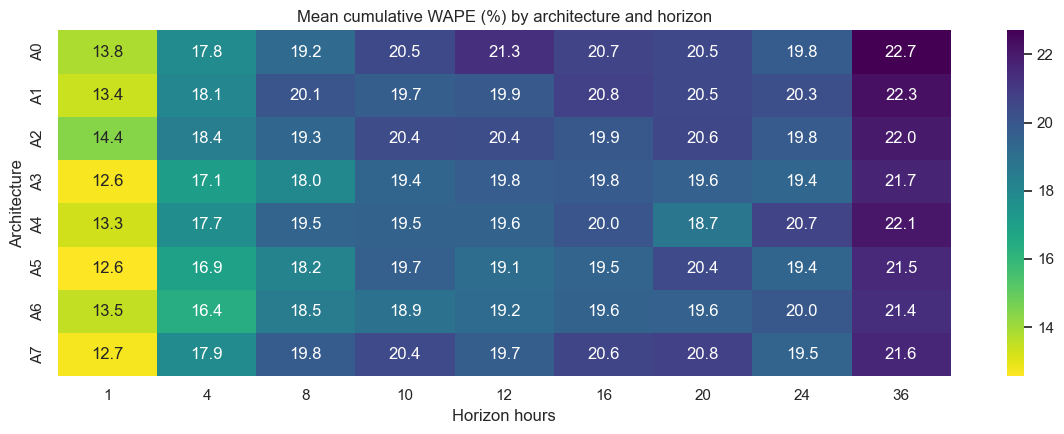

/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_19681/2235908707.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall_df, x='architecture_id', y='wape_mean', palette='deep', errorbar=None)


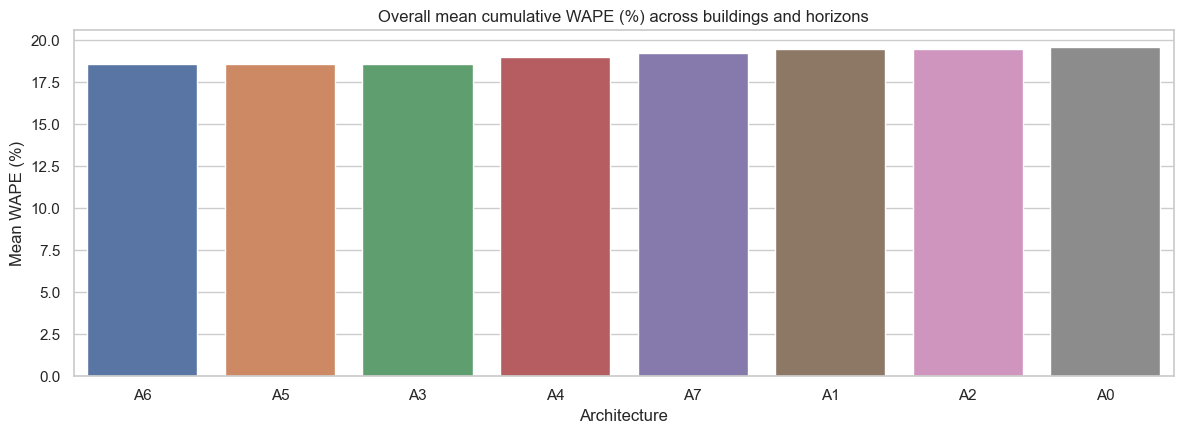

: 

In [ ]:
# Section 5 - Summaries, rankings, and compact plots

from scipy import stats


def mean_ci95(x: pd.Series) -> Tuple[float, float, float]:
    arr = pd.Series(x).dropna().astype(float).to_numpy()
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    mean = float(arr.mean())
    if len(arr) == 1:
        return mean, mean, mean
    lo, hi = stats.t.interval(0.95, len(arr) - 1, loc=mean, scale=stats.sem(arr))
    return mean, float(lo), float(hi)


if 'run_log_df' not in globals() or run_log_df.empty:
    print('No overnight run log available yet.')
else:
    ok_df = run_log_df.loc[run_log_df['status'] == 'ok'].copy()

    summary_rows = []
    for keys, sub in ok_df.groupby(['target_name', 'horizon_hours', 'architecture_id'], observed=True):
        target_name, horizon_hours, architecture_id = keys
        w_mean, w_lo, w_hi = mean_ci95(sub['wape_pct'])
        d_mean, d_lo, d_hi = mean_ci95(sub['delta_wape_vs_baseline'])
        summary_rows.append({
            'target_name': target_name,
            'horizon_hours': horizon_hours,
            'architecture_id': architecture_id,
            'n_runs': len(sub),
            'wape_mean': w_mean,
            'wape_ci95_low': w_lo,
            'wape_ci95_high': w_hi,
            'delta_vs_baseline_mean': d_mean,
            'delta_vs_baseline_ci95_low': d_lo,
            'delta_vs_baseline_ci95_high': d_hi,
            'rmse_mean': float(sub['rmse'].mean()),
            'mae_mean': float(sub['mae'].mean()),
            'r2_mean': float(sub['r2'].mean()),
            'baseline_wape_mean': float(sub['baseline_wape_pct'].mean()),
            'mean_n_train_seq': float(sub['n_train_seq'].mean()),
            'mean_n_test_seq': float(sub['n_test_seq'].mean()),
        })
    summary_by_horizon_df = pd.DataFrame(summary_rows).merge(
        architecture_catalog_df[['architecture_id', 'architecture_label', 'lookback_hours', 'lstm_stack', 'dropout', 'dense_units']],
        on='architecture_id',
        how='left',
    ).sort_values(['horizon_hours', 'wape_mean', 'rmse_mean', 'lookback_hours']).reset_index(drop=True)

    overall_df = (
        ok_df.groupby(['architecture_id'], observed=True)
        .agg(
            wape_mean=('wape_pct', 'mean'),
            wape_std=('wape_pct', 'std'),
            rmse_mean=('rmse', 'mean'),
            mae_mean=('mae', 'mean'),
            r2_mean=('r2', 'mean'),
            baseline_wape_mean=('baseline_wape_pct', 'mean'),
            delta_vs_baseline_mean=('delta_wape_vs_baseline', 'mean'),
            mean_n_train_seq=('n_train_seq', 'mean'),
            mean_n_test_seq=('n_test_seq', 'mean'),
            n_runs=('building', 'count'),
        )
        .reset_index()
        .merge(architecture_catalog_df[['architecture_id', 'architecture_label', 'lookback_hours', 'lstm_stack', 'dropout', 'dense_units']], on='architecture_id', how='left')
        .sort_values(['wape_mean', 'rmse_mean', 'lookback_hours'])
        .reset_index(drop=True)
    )

    best_by_horizon_df = (
        summary_by_horizon_df.sort_values(['horizon_hours', 'wape_mean', 'rmse_mean', 'lookback_hours'])
        .groupby('horizon_hours', as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    summary_by_horizon_df.to_csv(SUMMARY_HORIZON_FILE, index=False)
    overall_df.to_csv(SUMMARY_OVERALL_FILE, index=False)
    best_by_horizon_df.to_csv(BEST_FILE, index=False)

    display(summary_by_horizon_df)
    display(overall_df)
    display(best_by_horizon_df)

    print(f'Saved horizon summary to {SUMMARY_HORIZON_FILE}')
    print(f'Saved overall summary to {SUMMARY_OVERALL_FILE}')
    print(f'Saved best-by-horizon table to {BEST_FILE}')

    heatmap_df = summary_by_horizon_df.pivot(index='architecture_id', columns='horizon_hours', values='wape_mean')
    plt.figure(figsize=(12, 4.5))
    sns.heatmap(heatmap_df, annot=True, fmt='.1f', cmap='viridis_r')
    plt.title('Mean cumulative WAPE (%) by architecture and horizon')
    plt.xlabel('Horizon hours')
    plt.ylabel('Architecture')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4.5))
    sns.barplot(data=overall_df, x='architecture_id', y='wape_mean', palette='deep', errorbar=None)
    plt.title('Overall mean cumulative WAPE (%) across buildings and horizons')
    plt.xlabel('Architecture')
    plt.ylabel('Mean WAPE (%)')
    plt.tight_layout()
    plt.show()


## After the overnight run

The key files to inspect tomorrow are:

- [cumulative_m0_overnight_architecture_run_log_20032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_run_log_20032026.csv)
- [cumulative_m0_overnight_architecture_summary_by_horizon_20032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_summary_by_horizon_20032026.csv)
- [cumulative_m0_overnight_architecture_summary_overall_20032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_summary_overall_20032026.csv)
- [cumulative_m0_overnight_architecture_best_by_horizon_20032026.csv](/Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/cumulative_m0_overnight_architecture_best_by_horizon_20032026.csv)

The main question to answer is not just “which architecture wins overall?”, but also:

- does `48h` consistently beat the `24h` baseline?
- does `72h` help on the longer cumulative horizons or only on some of them?
- is the single-layer family still best once the run is scaled back up to the broader `05` cohort?
- and how much of the remaining error is simply due to horizon difficulty rather than bad architecture choice?
